In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
coffee_data = pd.read_csv("C:/Users/sando/Documents/Data Analytics/03 - Coffe-data for cleaning/dirty_cafe_sales.csv")
coffee_data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
coffee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [4]:
coffee_data.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [5]:
coffee_data.duplicated().sum()

np.int64(0)

In [6]:
coffee_data.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [7]:
coffee_data['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

Data Cleaning

Data types

In [8]:
coffee_data[['Quantity', 'Price Per Unit', 'Total Spent']] = (
    coffee_data[['Quantity', 'Price Per Unit', 'Total Spent']]
    .apply(pd.to_numeric, errors='coerce')
)
coffee_data['Transaction Date'] = pd.to_datetime(coffee_data['Transaction Date'], errors='coerce')

In [9]:
coffee_data[coffee_data.isin(['ERROR', 'UNKNOWN'])] = np.nan
coffee_data.isna().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [10]:
coffee_data = coffee_data.drop_duplicates()
coffee_data.duplicated().sum()

np.int64(0)

In [11]:
coffee_data_2=coffee_data[['Item','Price Per Unit']]

In [12]:
coffee_data_2=coffee_data_2.drop_duplicates()

In [13]:
coffee_data_2=coffee_data_2.dropna()

In [14]:
coffee_data_2

,Item,Price Per Unit
0,Coffee,2.0
1,Cake,3.0
2,Cookie,1.0
3,Salad,5.0
5,Smoothie,4.0
7,Sandwich,4.0
17,Juice,3.0
42,Tea,1.5


Price per Unit

In [17]:
item_price_map = {
    'Coffee' : 2,
    'Cake' : 3,
    'Cookie' : 1,
    'Salad' : 5,
    'Smoothie' : 4,
    'Sandwich' : 4,
    'Juice' : 3,
    'Tea' : 1.5
}
coffee_data['Price Per Unit']=coffee_data['Price Per Unit'].fillna(coffee_data['Item'].map(item_price_map))
coffee_data['Price Per Unit'].isna().sum()

np.int64(54)

Items

In [18]:
price_item_map = {
    2 : 'Coffee',
    1 : 'Cookie',
    5 : 'Salad',
    1.5 : 'Tea'    
}
coffee_data['Item']=coffee_data['Item'].fillna(coffee_data['Price Per Unit'].map(price_item_map))
coffee_data['Item'].isna().sum()

np.int64(501)

Total Spent

In [20]:
coffee_data['Total Spent']=coffee_data['Total Spent'].fillna(coffee_data['Quantity']*coffee_data['Price Per Unit'])
coffee_data['Total Spent'].isna().sum()

np.int64(23)

Dependent Values


Quantity

In [21]:
coffee_data['Quantity']=coffee_data['Quantity'].fillna(coffee_data['Total Spent']/coffee_data['Price Per Unit'])
coffee_data['Quantity'].isna().sum()

np.int64(23)

Price per Unit

In [22]:
coffee_data['Price Per Unit']=coffee_data['Price Per Unit'].fillna(coffee_data['Total Spent']/coffee_data['Quantity'])
coffee_data['Price Per Unit'].isna().sum()

np.int64(6)

save cleaned file

In [40]:
#coffee_data.to_csv("C:/Users/sando/Documents/Data Analytics/03 - Coffe-data for cleaning/dirty_cafe_sales_cleaned.csv", index=False)

EDA

In [23]:
coffee_data['Total Spent'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)

mean       8.93
median     8.00
std        6.00
min        1.00
max       25.00
Name: Total Spent, dtype: float64

In [24]:
coffee_data['Quantity'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)

mean      3.02
median    3.00
std       1.42
min       1.00
max       5.00
Name: Quantity, dtype: float64

Products Revenue

In [25]:
item = coffee_data.loc[coffee_data['Item'] != 'UNKNOWN', 'Item']

revenue_products = coffee_data.groupby(item)['Total Spent'].sum()
revenue_products

Item
Cake        10404.0
Coffee       7756.0
Cookie       3585.0
Juice       10515.0
Salad       19075.0
Sandwich    13716.0
Smoothie    13344.0
Tea          5433.0
Name: Total Spent, dtype: float64

Items sold

In [26]:
coffee_data.groupby(item)['Quantity'].sum()

Item
Cake        3468.0
Coffee      3878.0
Cookie      3585.0
Juice       3505.0
Salad       3815.0
Sandwich    3429.0
Smoothie    3336.0
Tea         3622.0
Name: Quantity, dtype: float64

Number of transactions per product

In [27]:
item.value_counts()

Item
Coffee      1284
Salad       1270
Cookie      1209
Tea         1199
Juice       1171
Cake        1139
Sandwich    1131
Smoothie    1096
Name: count, dtype: int64

Average transaction value per product

In [29]:
coffee_data.groupby(item)['Quantity'].mean().round(2)

Item
Cake        3.05
Coffee      3.03
Cookie      2.97
Juice       3.00
Salad       3.01
Sandwich    3.04
Smoothie    3.05
Tea         3.02
Name: Quantity, dtype: float64

The best-selling product 

In [30]:
best = coffee_data.groupby(item)['Quantity'].sum().max()
product = coffee_data.groupby(item)['Quantity'].sum()
highest_product_quantity = product.loc[product.values == best].idxmax()
highest_product_quantity

'Coffee'

Payment analysis

In [31]:
payment_method = coffee_data.loc[coffee_data['Payment Method'] != 'UNKNOWN', 'Payment Method']
payment_method.value_counts()

Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

In [32]:
payment_counts = payment_method.value_counts()

payment_percentage = (
    payment_counts / payment_counts.sum() * 100
).round(2)

payment_percentage

Payment Method
Digital Wallet    33.58
Credit Card       33.32
Cash              33.10
Name: count, dtype: float64

Takeaway analysis

In [33]:
location = coffee_data.loc[coffee_data['Location'] != 'UNKNOWN', 'Location']
location.value_counts()

Location
Takeaway    3022
In-store    3017
Name: count, dtype: int64

In [34]:
coffee_data.groupby(location)['Total Spent'].sum()

Location
In-store    27174.0
Takeaway    26552.5
Name: Total Spent, dtype: float64

Analysis by dates

In [35]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]


month = coffee_data['Transaction Date'].dt.month_name()
monthly_sales = coffee_data.groupby(month)['Total Spent'].sum()
monthly_sales = monthly_sales.reindex(month_order)
monthly_sales

Transaction Date
January      7254.0
February     6644.0
March        7216.0
April        7179.0
May          6957.5
June         7353.0
July         6877.5
August       7112.5
September    6871.0
October      7314.0
November     6967.0
December     7177.0
Name: Total Spent, dtype: float64

In [36]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_of_week = coffee_data['Transaction Date'].dt.day_name()
day_of_week_sales = coffee_data.groupby(day_of_week)['Total Spent'].sum().reindex(day_order)
day_of_week_sales

Transaction Date
Monday       12140.0
Tuesday      12039.5
Wednesday    11680.5
Thursday     12401.5
Friday       12334.0
Saturday     12039.5
Sunday       12287.5
Name: Total Spent, dtype: float64

Plots

Revenue by product

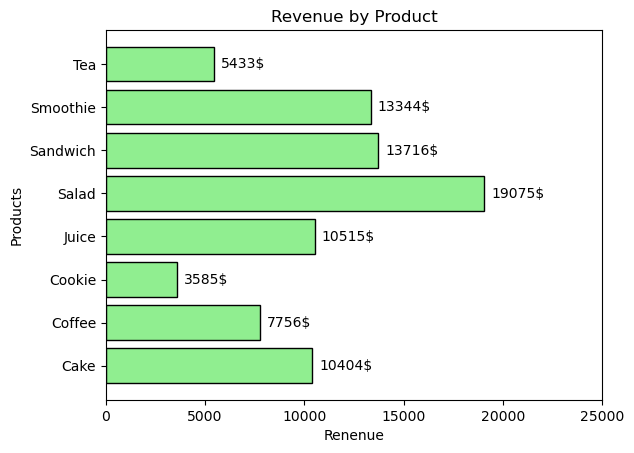

In [37]:
fig, ax = plt.subplots()
barh_container = ax.barh(revenue_products.index, revenue_products.values,
                         color= 'lightgreen',
                         edgecolor='black',
                         )
ax.set(ylabel='Products', xlabel='Renenue', title='Revenue by Product')
ax.bar_label(barh_container, fmt=lambda x: f'{int(x):d}$', padding=5)
plt.xlim(right=25000)
plt.show()

Quantity by Product

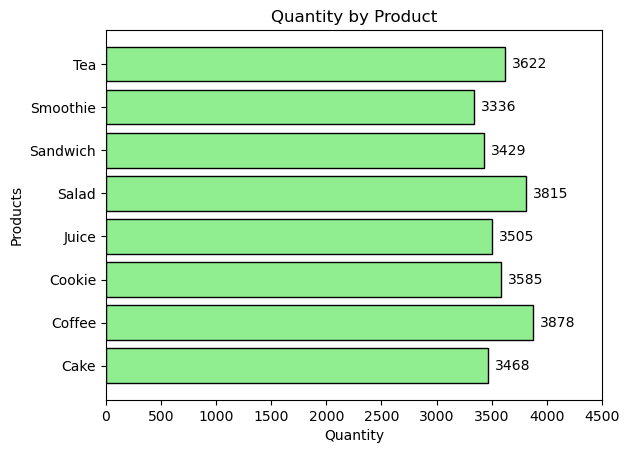

In [39]:
quantity = coffee_data.groupby(item)['Quantity'].sum().dropna()
fig, ax = plt.subplots()
barh_container = plt.barh(quantity.index, quantity.values,  color= 'lightgreen',
                                                            edgecolor='black',
                                                            )
ax.set(ylabel='Products', xlabel='Quantity', title='Quantity by Product')
ax.bar_label(barh_container, fmt= lambda x:f'{int(x):d}', padding= 5)
plt.xlim(right= 4500)
plt.show()

Visualisation will be done by PowerBI